# 06. Сравнения PWM, PDM, delta-sigma и многоканальных схем

Этот ноутбук собирает несколько методов рядом. Сравнение не является финальной метрикой качества усилителя: здесь нет силового каскада, фильтра, трансформатора, нагрузки и dead time. Но это быстрый способ увидеть временную реализацию, спектральные пики и ошибку простой усредняющей реконструкции.

In [1]:
from pathlib import Path
import sys

HERE = Path.cwd().resolve()
if (HERE / "tutorial_helpers.py").exists():
    TUTORIAL_DIR = HERE
elif (HERE / "tutorials" / "tutorial_helpers.py").exists():
    TUTORIAL_DIR = HERE / "tutorials"
else:
    raise RuntimeError("Run this notebook from the repository root or from the tutorials folder")

path_text = str(TUTORIAL_DIR)
if path_text not in sys.path:
    sys.path.insert(0, path_text)

import matplotlib.pyplot as plt
import numpy as np

from tutorial_helpers import (
    configure_plots,
    grouped_fifo_channel_waveforms,
    load_pwm_lab,
    plot_bitstream,
    plot_channel_stack,
    plot_moving_average_reconstruction,
    plot_pwm_carrier_output,
    plot_spectra,
    print_peak_table,
    pwm_kind2_channel_waveforms,
    show_grouped_mapping,
    time_us,
)

pl = load_pwm_lab()
configure_plots()

## Общий вход и PWM-варианты

In [2]:
config = pl.PwmConfig(f_clk=60e6, f_pwm=1e6, resolution_bits=8)
f_signal = 20e3
n_periods = 1024
n_clk = n_periods * config.period_samples

_, x_clk = pl.sine_samples(freq=f_signal, sample_rate=config.f_clk, n_samples=n_clk, amplitude=0.85)
_, x_pwm = pl.sine_samples(freq=f_signal, sample_rate=config.actual_f_pwm, n_samples=n_periods, amplitude=0.85)

pwm1 = pl.pwm_kind1(x_clk, config)
pwm2 = pl.pwm_kind2_latched(x_pwm, config)
pwm2_4ch = pl.pwm_kind2_multichannel_latched(x_pwm, config, channels=4)

samples_per_period = 4
f_data_grouped = samples_per_period * config.actual_f_pwm
_, x_grouped = pl.sine_samples(
    freq=f_signal,
    sample_rate=f_data_grouped,
    n_samples=n_periods * samples_per_period,
    amplitude=0.85,
)
pwm_grouped = pl.pwm_kind2_fifo_grouped_multichannel(
    x_grouped,
    config,
    samples_per_period=samples_per_period,
    channels=8,
)

## PDM и delta-sigma варианты

In [3]:
f_data = 4e6
n_data = 8192
_, x_data = pl.sine_samples(freq=f_signal, sample_rate=f_data, n_samples=n_data, amplitude=0.85)

pdm1 = pl.pdm_first_order(x_data)
pdm2 = pl.pdm_second_order(x_data)
ds1 = pl.delta_sigma_first_order(x_data)
ds2 = pl.delta_sigma_second_order(x_data)
ds2_4ch = pl.delta_sigma_second_order_multichannel(x_data, channels=4)

## Спектры PWM-группы

Все эти потоки существуют на `f_clk`.

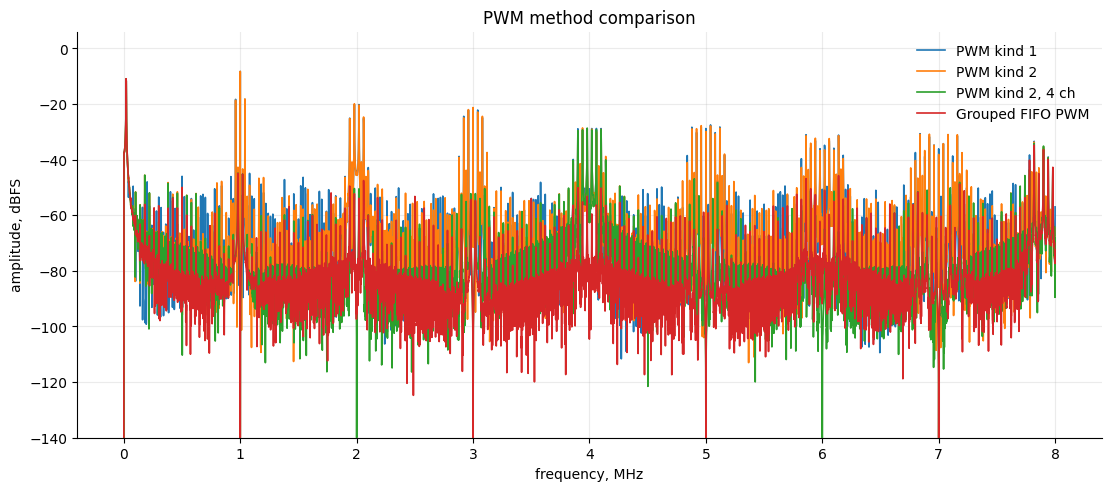

In [4]:
plot_spectra(
    {
        "PWM kind 1": pwm1,
        "PWM kind 2": pwm2,
        "PWM kind 2, 4 ch": pwm2_4ch,
        "Grouped FIFO PWM": pwm_grouped,
    },
    sample_rate=config.f_clk,
    f_max=8e6,
    f_scale=1e6,
    f_unit="MHz",
    title="PWM method comparison",
);

## Спектры PDM/delta-sigma-группы

Эти потоки существуют на `f_data`.

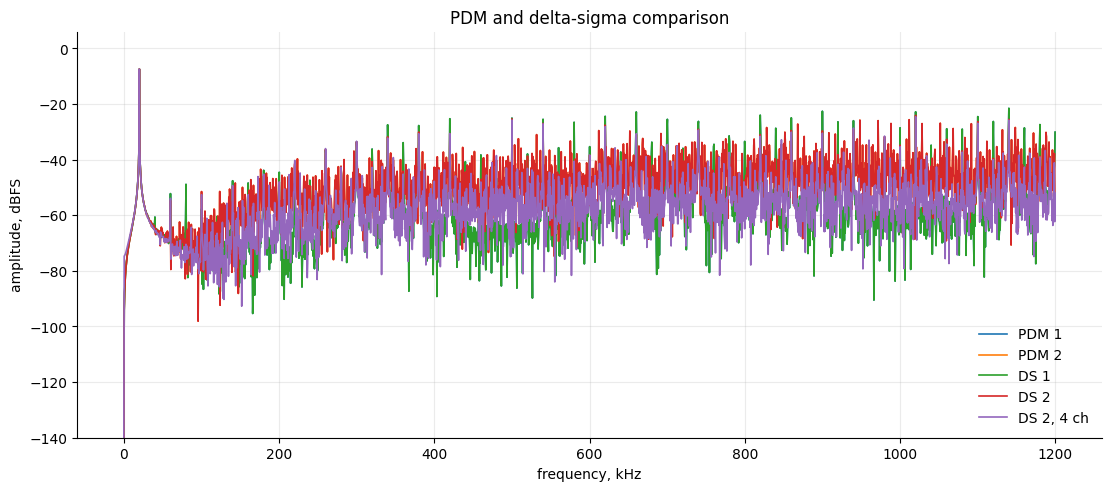

In [5]:
plot_spectra(
    {
        "PDM 1": pdm1,
        "PDM 2": pdm2,
        "DS 1": ds1,
        "DS 2": ds2,
        "DS 2, 4 ch": ds2_4ch,
    },
    sample_rate=f_data,
    f_max=1.2e6,
    f_scale=1e3,
    f_unit="kHz",
    title="PDM and delta-sigma comparison",
);

## Численная ошибка простой реконструкции

Метрика ниже специально простая: берем среднее по фиксированному окну и считаем RMS-ошибку относительно такого же усредненного входа.

In [6]:
def rms(x):
    values = np.asarray(x, dtype=np.float64)
    return float(np.sqrt(np.mean(values * values)))

rows = []

pwm2_avg = pl.moving_average_decimate(pwm2, config.period_samples)
pwm2_4ch_avg = pl.moving_average_decimate(pwm2_4ch, config.period_samples)
pwm_grouped_avg = pl.moving_average_decimate(pwm_grouped, config.period_samples)
x_grouped_avg = pl.moving_average_decimate(x_grouped, samples_per_period)

rows.append(("PWM kind 2", rms(pwm2_avg - x_pwm[:pwm2_avg.size])))
rows.append(("PWM kind 2, 4 ch", rms(pwm2_4ch_avg - x_pwm[:pwm2_4ch_avg.size])))
rows.append(("Grouped FIFO PWM", rms(pwm_grouped_avg - x_grouped_avg[:pwm_grouped_avg.size])))

average_factor = 64
x_data_avg = pl.moving_average_decimate(x_data, average_factor)
for name, y in [("PDM 1", pdm1), ("PDM 2", pdm2), ("DS 1", ds1), ("DS 2", ds2), ("DS 2, 4 ch", ds2_4ch)]:
    y_avg = pl.moving_average_decimate(y, average_factor)
    rows.append((name, rms(y_avg - x_data_avg[:y_avg.size])))

for name, err in rows:
    print(f"{name:20s}  RMS error = {err:.6g}")

PWM kind 2            RMS error = 0.00858296
PWM kind 2, 4 ch      RMS error = 0.00858296
Grouped FIFO PWM      RMS error = 0.00410143
PDM 1                 RMS error = 0.00742927
PDM 2                 RMS error = 0.00734027
DS 1                  RMS error = 0.00742927
DS 2                  RMS error = 0.00734027
DS 2, 4 ch            RMS error = 0.00360264


## LFM/чирп как вход для быстрой проверки полосы

Для частотно-модулированного входа удобно смотреть не только один тон, а полосу частот. Здесь используется `lfm_samples(...)` из текущего пакета.

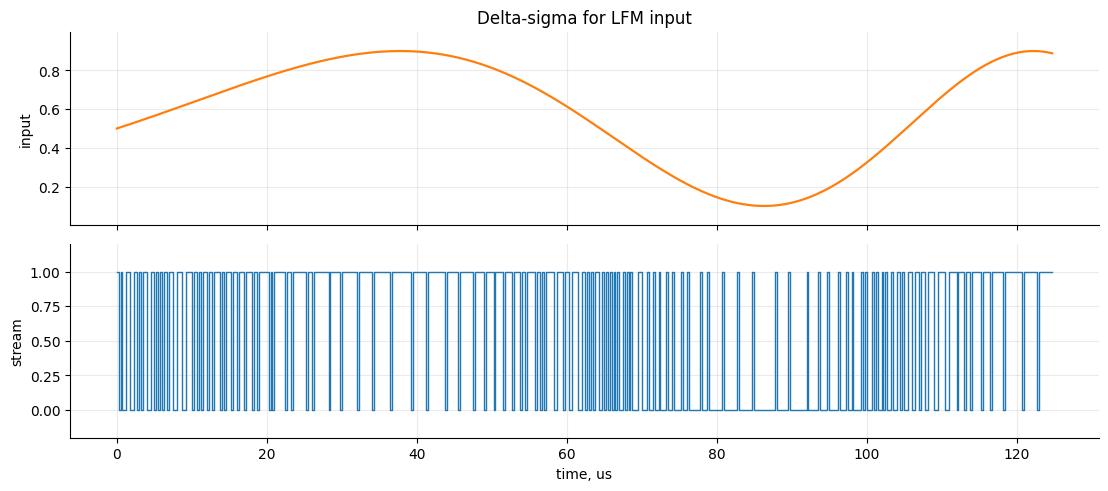

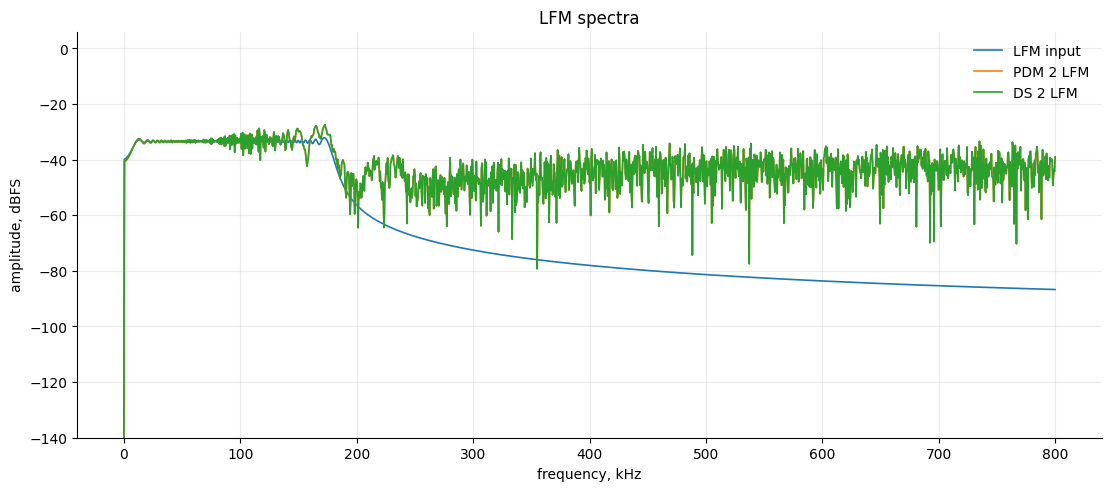

In [7]:
_, x_lfm = pl.lfm_samples(f_start=5e3, f_end=180e3, sample_rate=f_data, n_samples=n_data, amplitude=0.8)
ds_lfm = pl.delta_sigma_second_order(x_lfm)
pdm_lfm = pl.pdm_second_order(x_lfm)

plot_bitstream(x_lfm, ds_lfm, sample_rate=f_data, max_points=500, title="Delta-sigma for LFM input");
plot_spectra(
    {"LFM input": x_lfm, "PDM 2 LFM": pdm_lfm, "DS 2 LFM": ds_lfm},
    sample_rate=f_data,
    f_max=800e3,
    f_scale=1e3,
    f_unit="kHz",
    title="LFM spectra",
);